In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 79.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import os
import zipfile

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve
)
import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE

from mne.preprocessing import Xdawn
from mne.decoding import XdawnTransformer
from google.colab import drive

In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
BASE = "/content/drive/MyDrive/Colab Notebooks"
ZIP_PATH_EPOCHS = os.path.join(BASE, "outputs", "epochs2.zip")
OUT_DIR_EPOCHS = os.path.join(BASE, "outputs", "epochs_extracted")
ZIP_PATH_FEATURES = os.path.join(BASE, "outputs", "features.zip")
OUT_DIR_FEATURES = os.path.join(BASE, "outputs", "features_extracted")

os.makedirs(OUT_DIR_EPOCHS, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH_EPOCHS, "r") as z:
    z.extractall(OUT_DIR_EPOCHS)

with zipfile.ZipFile(ZIP_PATH_FEATURES, "r") as z:
    z.extractall(OUT_DIR_FEATURES)

df_epochs = pd.concat(
    [pd.read_parquet(os.path.join(OUT_DIR_EPOCHS, f)) for f in os.listdir(OUT_DIR_EPOCHS) if f.endswith(".parquet")],
    ignore_index=True
)

df_spat = pd.concat(
    [pd.read_parquet(os.path.join(OUT_DIR_FEATURES, f)) for f in os.listdir(OUT_DIR_FEATURES) if f.endswith("spatial_clean.parquet")],
    ignore_index=True
)

df_temp = pd.concat(
    [pd.read_parquet(os.path.join(OUT_DIR_FEATURES, f)) for f in os.listdir(OUT_DIR_FEATURES) if f.endswith("temporal_clean.parquet")],
    ignore_index=True
)

df_freq = pd.concat(
    [pd.read_parquet(os.path.join(OUT_DIR_FEATURES, f)) for f in os.listdir(OUT_DIR_FEATURES) if f.endswith("frequency_clean.parquet")],
    ignore_index=True
)


In [ ]:
y = df_epochs['label']

In [ ]:
print("Epochs:", len(df_epochs))
print("Columns:", df_epochs.columns.tolist())

Epochs: 28189
Columns: ['subject', 'epoch', 'label', 'data']


In [ ]:
print("Epochs:", len(df_freq))
print("Columns:", df_freq.columns.tolist())

Epochs: 28189
Columns: ['EEG_Pz_bp_alpha', 'EEG_Pz_bp_beta', 'EEG_Cz_bp_alpha', 'EEG_Cz_bp_beta', 'EEG_CPz_bp_alpha', 'EEG_CPz_bp_beta', 'EEG_P3_bp_alpha', 'EEG_P3_bp_beta', 'EEG_P4_bp_alpha', 'EEG_P4_bp_beta', 'EEG_CP3_bp_alpha', 'EEG_CP3_bp_beta', 'EEG_CP4_bp_alpha', 'EEG_CP4_bp_beta', 'subject', 'label']


In [ ]:
print("Epochs:", len(df_temp))
print("Columns:", df_temp.columns.tolist())

Epochs: 28189
Columns: ['EEG_Pz_mean_6', 'EEG_Pz_max_6', 'EEG_Pz_min_6', 'EEG_Pz_auc_6', 'EEG_Pz_mean_18', 'EEG_Pz_max_18', 'EEG_Pz_min_18', 'EEG_Pz_auc_18', 'EEG_Pz_mean_30', 'EEG_Pz_max_30', 'EEG_Pz_min_30', 'EEG_Pz_auc_30', 'EEG_Pz_mean_42', 'EEG_Pz_max_42', 'EEG_Pz_min_42', 'EEG_Pz_auc_42', 'EEG_Pz_mean_54', 'EEG_Pz_max_54', 'EEG_Pz_min_54', 'EEG_Pz_auc_54', 'EEG_Pz_mean_66', 'EEG_Pz_max_66', 'EEG_Pz_min_66', 'EEG_Pz_auc_66', 'EEG_Pz_mean_78', 'EEG_Pz_max_78', 'EEG_Pz_min_78', 'EEG_Pz_auc_78', 'EEG_Pz_std', 'EEG_Pz_skew', 'EEG_Pz_kurtosis', 'EEG_Pz_ptp', 'EEG_Pz_peak_amp', 'EEG_Pz_peak_lat', 'EEG_Cz_mean_6', 'EEG_Cz_max_6', 'EEG_Cz_min_6', 'EEG_Cz_auc_6', 'EEG_Cz_mean_18', 'EEG_Cz_max_18', 'EEG_Cz_min_18', 'EEG_Cz_auc_18', 'EEG_Cz_mean_30', 'EEG_Cz_max_30', 'EEG_Cz_min_30', 'EEG_Cz_auc_30', 'EEG_Cz_mean_42', 'EEG_Cz_max_42', 'EEG_Cz_min_42', 'EEG_Cz_auc_42', 'EEG_Cz_mean_54', 'EEG_Cz_max_54', 'EEG_Cz_min_54', 'EEG_Cz_auc_54', 'EEG_Cz_mean_66', 'EEG_Cz_max_66', 'EEG_Cz_min_66', 'EEG

In [ ]:
print("Epochs:", len(df_spat))
print("Columns:", df_spat.columns.tolist())

Epochs: 28189
Columns: ['xd_comp0_mean', 'xd_comp0_max', 'xd_comp0_min', 'xd_comp0_auc', 'xd_comp1_mean', 'xd_comp1_max', 'xd_comp1_min', 'xd_comp1_auc', 'xd_comp2_mean', 'xd_comp2_max', 'xd_comp2_min', 'xd_comp2_auc', 'xd_comp3_mean', 'xd_comp3_max', 'xd_comp3_min', 'xd_comp3_auc', 'xd_comp4_mean', 'xd_comp4_max', 'xd_comp4_min', 'xd_comp4_auc', 'xd_comp5_mean', 'xd_comp5_max', 'xd_comp5_min', 'xd_comp5_auc', 'xd_comp6_mean', 'xd_comp6_max', 'xd_comp6_min', 'xd_comp6_auc', 'xd_comp7_mean', 'xd_comp7_max', 'xd_comp7_min', 'xd_comp7_auc', 'xd_comp8_mean', 'xd_comp8_max', 'xd_comp8_min', 'xd_comp8_auc', 'xd_comp9_mean', 'xd_comp9_max', 'xd_comp9_min', 'xd_comp9_auc', 'xd_comp10_mean', 'xd_comp10_max', 'xd_comp10_min', 'xd_comp10_auc', 'xd_comp11_mean', 'xd_comp11_max', 'xd_comp11_min', 'xd_comp11_auc', 'subject', 'label']


In [ ]:
models = {
"LogReg": LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear"),
"LDA_shrink": LDA(solver="lsqr", shrinkage="auto"),
"LinearSVM": LinearSVC(class_weight="balanced"),
"XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=1),
"LightGBM": lgb.LGBMClassifier(class_weight='balanced')
}

# Funciones

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import LinearSVC
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_recall_curve

from imblearn.over_sampling import SMOTE
from mne.decoding import XdawnTransformer


def best_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1s = 2 * precision * recall / (precision + recall + 1e-8)
    best_idx = np.argmax(f1s)
    return thresholds[best_idx]


def evaluate_metrics(y_true, y_score, threshold):
    y_pred = (y_score > threshold).astype(int)
    return {
        "acc": accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_score),
        "f1":  f1_score(y_true, y_pred)
    }


def train_classic(
    X,
    y,
    subjects,
    models,
    n_splits=5,
    n_xdawn=4,
    use_smote=False,
    random_state=42,
    verbose=True,
    feature_type=None
):
    """
    Entrena y evalúa modelos clásicos usando validación cruzada por sujeto.

    Retorna
    -------
    results_df : pd.DataFrame
        Métricas agregadas por fold
    preds_df : pd.DataFrame
        Predicciones por muestra (para ensemble)
    """

    gkf = GroupKFold(n_splits=n_splits)
    rows = []
    pred_rows = []

    for fold, (tr, te) in enumerate(gkf.split(X, y, subjects)):
        if verbose:
            print(f"\n===== Fold {fold+1}/{n_splits} =====")

        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]

        # ---- xDAWN solo si los datos son 3D ----
        if X_tr.ndim == 3:
            xd = XdawnTransformer(n_components=n_xdawn)
            X_tr_xd = xd.fit_transform(X_tr.transpose(0, 2, 1), y_tr)
            X_te_xd = xd.transform(X_te.transpose(0, 2, 1))
        else:
            X_tr_xd, X_te_xd = X_tr, X_te

        # ---- Flatten si es 3D ----
        if X_tr_xd.ndim == 3:
            X_tr_f = X_tr_xd.reshape(len(X_tr_xd), -1)
            X_te_f = X_te_xd.reshape(len(X_te_xd), -1)
        else:
            X_tr_f, X_te_f = X_tr_xd, X_te_xd

        # ---- Optional SMOTE (TRAIN only) ----
        if use_smote:
            sm = SMOTE(random_state=random_state)
            X_tr_fit, y_tr_fit = sm.fit_resample(X_tr_f, y_tr)
        else:
            X_tr_fit, y_tr_fit = X_tr_f, y_tr

        # ---- Models ----
        for name, clf in models.items():
            clf.fit(X_tr_fit, y_tr_fit)

            if hasattr(clf, "predict_proba"):
                tr_score = clf.predict_proba(X_tr_f)[:, 1]
                te_score = clf.predict_proba(X_te_f)[:, 1]
            else:
                tr_score = clf.decision_function(X_tr_f)
                te_score = clf.decision_function(X_te_f)

            # Threshold tunado SOLO en train
            thr = best_threshold(y_tr, tr_score)
            metrics = evaluate_metrics(y_te, te_score, thr)

            rows.append({
                "model": name,
                "fold": fold,
                "acc": metrics["acc"],
                "auc": metrics["auc"],
                "f1": metrics["f1"]
            })

            # 🔹 Guardar predicciones por muestra
            for i, idx in enumerate(te):
                pred_rows.append({
                    "model": name,
                    "feature_type": feature_type,
                    "fold": fold,
                    "idx": idx,
                    "y_true": y[idx],
                    "y_score": te_score[i],
                    "thr": thr
                })

            if verbose:
                print(
                    f"{name:10s} | ACC={metrics['acc']:.3f} | "
                    f"AUC={metrics['auc']:.3f} | F1={metrics['f1']:.3f}"
                )

    results_df = pd.DataFrame(rows)
    preds_df = pd.DataFrame(pred_rows)

    return results_df, preds_df

def plot_metrics(
    results_df,
    title,
    metrics=("acc", "auc", "f1"),
    metric_names=("ACC", "AUC", "F1"),
):
    """
    Dibuja diagramas de caja (boxplots) de métricas de validación cruzada para cada modelo.

    Parámetros
    ----------
    results_df : pd.DataFrame
        Columnas: ['model', 'fold', 'acc', 'auc', 'f1']
    """

    sns.set(style="whitegrid")

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5), sharey=False)

    if len(metrics) == 1:
        axes = [axes]

    for ax, metric, metric_name in zip(axes, metrics, metric_names):
        sns.boxplot(data=results_df, x="model", y=metric, ax=ax)
        sns.stripplot(data=results_df, x="model", y=metric, ax=ax, color="black", alpha=0.4)
        ax.set_title(metric_name)
        ax.set_xlabel("Model")
        ax.set_ylabel(metric_name)
        ax.set_ylim(0, 1)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def ensemble_soft_voting_from_preds(
    preds_df,
    threshold=0.65,
    feature_types=("Temporal", "Espacial", "Frecuencia")
):
    """
    Construye un ensemble soft voting usando predicciones ya calculadas.

    Retorna
    -------
    results_df : pd.DataFrame
        Métricas por modelo y fold (análogas a train_classic)
    ensemble_preds_df : pd.DataFrame
        Predicciones del ensemble por muestra
    """

    rows = []
    ens_pred_rows = []

    for model in preds_df["model"].unique():
        df_model = preds_df[preds_df["model"] == model]

        for fold in sorted(df_model["fold"].unique()):
            df_fold = df_model[df_model["fold"] == fold]

            # ---- asegurar que están los 3 feature sets ----
            df_pivot = (
                df_fold[df_fold["feature_type"].isin(feature_types)]
                .pivot_table(
                    index="idx",
                    columns="feature_type",
                    values="y_score"
                )
                .dropna()
            )

            y_true = (
                df_fold
                .drop_duplicates("idx")
                .set_index("idx")
                .loc[df_pivot.index, "y_true"]
                .values
            )

            # ---- Soft voting ----
            avg_proba = df_pivot.values.mean(axis=1)
            y_pred = (avg_proba >= threshold).astype(int)

            # ---- Métricas ----
            rows.append({
                "model": model,
                "fold": fold,
                "acc": accuracy_score(y_true, y_pred),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred),
                "f1": f1_score(y_true, y_pred),
                "auc": roc_auc_score(y_true, avg_proba),
                "feature_type": f"Ensemble Soft Voting ({threshold})"
            })

            # ---- Guardar preds del ensemble ----
            for i, idx in enumerate(df_pivot.index):
                ens_pred_rows.append({
                    "model": model,
                    "fold": fold,
                    "idx": idx,
                    "y_true": y_true[i],
                    "y_score": avg_proba[i],
                    "y_pred": y_pred[i],
                    "feature_type": f"Ensemble Soft Voting ({threshold})"
                })

    results_df = pd.DataFrame(rows)
    ensemble_preds_df = pd.DataFrame(ens_pred_rows)

    return results_df, ensemble_preds_df


RNN

In [ ]:
class EpochDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class P300Net(nn.Module):
    def __init__(self, n_comp, hidden=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(n_comp, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(32, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        # x: (B, T, C)
        x = x.transpose(1, 2)  # (B, C, T)
        return self.net(x).squeeze(1)

def make_loss(y):
    n_pos = (y == 1).sum()
    n_neg = (y == 0).sum()
    pos_weight = torch.tensor([n_neg / n_pos], device=device)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def best_threshold(y_true, y_score):
    p, r, t = precision_recall_curve(y_true, y_score)
    f1 = 2 * p * r / (p + r + 1e-8)
    return t[np.argmax(f1)]

def compute_metrics(y_true, y_score):
    thr = best_threshold(y_true, y_score)
    y_pred = (y_score >= thr).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_score),
        "f1": f1_score(y_true, y_pred),
        "acc": accuracy_score(y_true, y_pred)
    }

def get_scores(model, loader):
    model.eval()
    out = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            out.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.concatenate(out)

def train_model(model, dl_tr, dl_va, y_tr, epochs=30, lr=3e-4):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = make_loss(y_tr)

    best_auc = 0
    best_state = None

    for ep in range(epochs):
        model.train()
        for xb, yb in dl_tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        y_tr_s = get_scores(model, dl_tr)
        y_va_s = get_scores(model, dl_va)

        tr_auc = roc_auc_score(dl_tr.dataset.y.numpy(), y_tr_s)
        va_auc = roc_auc_score(dl_va.dataset.y.numpy(), y_va_s)

        print(f"Ep {ep+1:02d} | Train AUC {tr_auc:.3f} | Val AUC {va_auc:.3f}")

        if va_auc > best_auc:
            best_auc = va_auc
            best_state = model.state_dict()

    model.load_state_dict(best_state)

# Epochs

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import zipfile


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve


from mne.decoding import XdawnTransformer

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
print("Device:", device)

Device: cuda


In [ ]:
X, y, subjects = [], [], []


for _, row in df_epochs.iterrows():
  chans = [np.asarray(ch, np.float32) for ch in row["data"]]
  min_len = min(len(ch) for ch in chans)
  chans = [ch[:min_len] for ch in chans]
  epoch = np.stack(chans, axis=0).T # (T, C)


  X.append(epoch)
  y.append(row["label"])
  subjects.append(row["subject"])


X = np.stack(X) # (N, T, C)
y = np.array(y)
subjects = np.array(subjects)


print("X:", X.shape)

X: (28189, 206, 16)


In [ ]:
# Ventana ERP (reduce coste RNN)
t0, t1 = 200, 550
X = X[:, t0:t1, :]
print("X recortado:", X.shape)


# Normalización por sujeto
for s in np.unique(subjects):
  idx = subjects == s
  mu = X[idx].mean(axis=(0,1), keepdims=True)
  sd = X[idx].std(axis=(0,1), keepdims=True)
  X[idx] = (X[idx] - mu) / (sd + 1e-6)

X recortado: (28189, 6, 16)


In [ ]:
gkf = GroupKFold(n_splits=5)
all_metrics = []

for fold, (tr, va) in enumerate(gkf.split(X, y, groups=subjects)):
    print(f"\n=== Fold {fold+1} ===")

    # --- Normalización (solo train) ---
    mu = X_tr.mean(axis=(0,1), keepdims=True)
    sd = X_tr.std(axis=(0,1), keepdims=True) + 1e-6
    X_tr = (X_tr - mu) / sd
    X_va = (X_va - mu) / sd

    # --- DataLoaders ---
    dl_tr = DataLoader(EpochDataset(X_tr, y[tr]), batch_size=32, shuffle=True)
    dl_va = DataLoader(EpochDataset(X_va, y[va]), batch_size=64)

    model = P300Net(n_comp=X_tr.shape[2])
    train_model(model, dl_tr, dl_va, y[tr])

    y_score = get_scores(model, dl_va)
    m = compute_metrics(y[va], y_score)
    all_metrics.append(m)

    print("Fold metrics:", m)



=== Fold 1 ===
Estimating covariance using EMPIRICAL
Done.
Estimating covariance using EMPIRICAL
Done.
Estimating covariance using EMPIRICAL
Done.
Computing rank from data with rank='full'
    data: rank 6 from info
Ep 01 | Train AUC 0.504 | Val AUC 0.528
Ep 02 | Train AUC 0.494 | Val AUC 0.529
Ep 03 | Train AUC 0.503 | Val AUC 0.530
Ep 04 | Train AUC 0.496 | Val AUC 0.531
Ep 05 | Train AUC 0.498 | Val AUC 0.528
Ep 06 | Train AUC 0.491 | Val AUC 0.528
Ep 07 | Train AUC 0.511 | Val AUC 0.528
Ep 08 | Train AUC 0.493 | Val AUC 0.526
Ep 09 | Train AUC 0.500 | Val AUC 0.526
Ep 10 | Train AUC 0.506 | Val AUC 0.524
Ep 11 | Train AUC 0.502 | Val AUC 0.521
Ep 12 | Train AUC 0.500 | Val AUC 0.520
Ep 13 | Train AUC 0.503 | Val AUC 0.521
Ep 14 | Train AUC 0.504 | Val AUC 0.515
Ep 15 | Train AUC 0.499 | Val AUC 0.516
Ep 16 | Train AUC 0.499 | Val AUC 0.515
Ep 17 | Train AUC 0.507 | Val AUC 0.518
Ep 18 | Train AUC 0.493 | Val AUC 0.517
Ep 19 | Train AUC 0.492 | Val AUC 0.510
Ep 20 | Train AUC 0.510

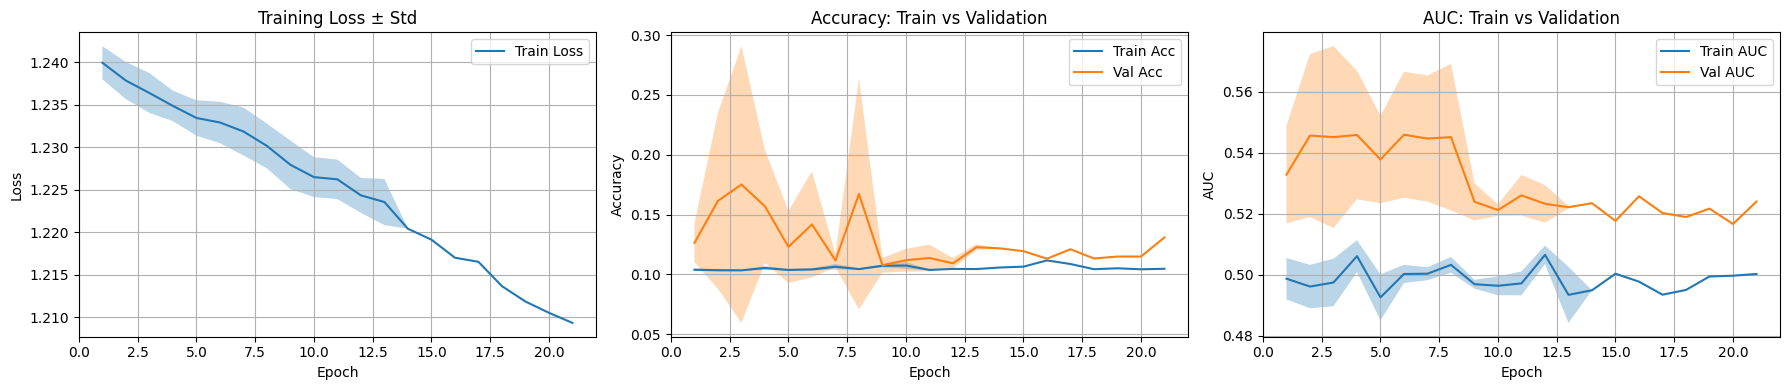

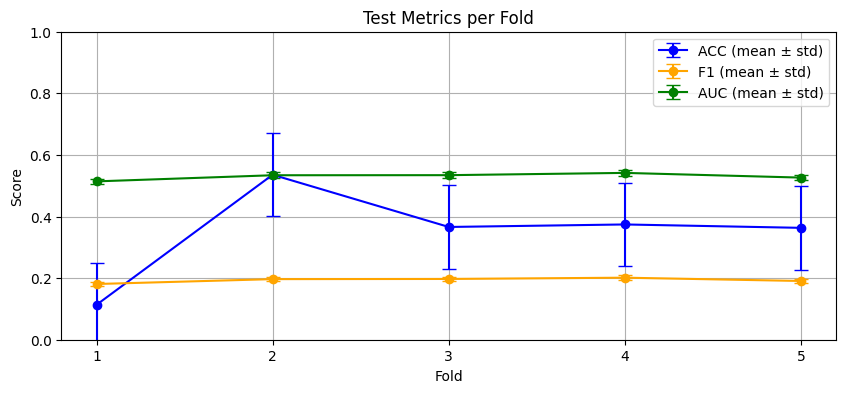


===== TEST METRICS (SUMMARY) =====
ACC: 0.351 ± 0.135
F1: 0.193 ± 0.007
AUC: 0.530 ± 0.009


In [ ]:
# Encuentra el máximo número de epochs entre folds
max_epochs = max(len(h["train_loss"]) for h in all_histories)

# Función para rellenar con np.nan hasta max_epochs
def pad_history(hist_list, key):
    return np.array([
        np.pad(h[key], (0, max_epochs - len(h[key])), constant_values=np.nan)
        for h in hist_list
    ])

train_loss = pad_history(all_histories, "train_loss")
train_acc  = pad_history(all_histories, "train_acc")
train_auc  = pad_history(all_histories, "train_auc")
val_acc    = pad_history(all_histories, "val_acc")
val_auc    = pad_history(all_histories, "val_auc")

epochs = np.arange(1, max_epochs + 1)

def mean_std(x):
    return np.nanmean(x, axis=0), np.nanstd(x, axis=0)

m_tr_loss, s_tr_loss = mean_std(train_loss)
m_tr_acc,  s_tr_acc  = mean_std(train_acc)
m_tr_auc,  s_tr_auc  = mean_std(train_auc)

m_va_acc,  s_va_acc  = mean_std(val_acc)
m_va_auc,  s_va_auc  = mean_std(val_auc)

plt.figure(figsize=(18, 4))

# ---- Loss ----
plt.subplot(1, 3, 1)
plt.plot(epochs, m_tr_loss, label="Train Loss")
plt.fill_between(epochs, m_tr_loss - s_tr_loss, m_tr_loss + s_tr_loss, alpha=0.3)
plt.title("Training Loss ± Std")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# ---- Accuracy ----
plt.subplot(1, 3, 2)
plt.plot(epochs, m_tr_acc, label="Train Acc")
plt.fill_between(epochs, m_tr_acc - s_tr_acc, m_tr_acc + s_tr_acc, alpha=0.3)
plt.plot(epochs, m_va_acc, label="Val Acc")
plt.fill_between(epochs, m_va_acc - s_va_acc, m_va_acc + s_va_acc, alpha=0.3)
plt.title("Accuracy: Train vs Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

# ---- AUC ----
plt.subplot(1, 3, 3)
plt.plot(epochs, m_tr_auc, label="Train AUC")
plt.fill_between(epochs, m_tr_auc - s_tr_auc, m_tr_auc + s_tr_auc, alpha=0.3)
plt.plot(epochs, m_va_auc, label="Val AUC")
plt.fill_between(epochs, m_va_auc - s_va_auc, m_va_auc + s_va_auc, alpha=0.3)
plt.title("AUC: Train vs Validation")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

results = {k: [m[k] for m in all_metrics] for k in all_metrics[0].keys()}

metrics = ["acc", "f1", "auc"]
colors = {"acc": "blue", "f1": "orange", "auc": "green"}

plt.figure(figsize=(10, 4))
for m in metrics:
    vals = np.array(results[m])
    mean_val = vals.mean()
    std_val  = vals.std()
    plt.errorbar(
        range(1, len(vals) + 1),
        vals,
        yerr=std_val,
        marker='o',
        capsize=5,
        color=colors[m],
        label=f"{m.upper()} (mean ± std)"
    )

plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Test Metrics per Fold")
plt.ylim(0, 1)
plt.xticks(range(1, len(vals) + 1))
plt.grid(True)
plt.legend()
plt.show()

print("\n===== TEST METRICS (SUMMARY) =====")
for m in metrics:
    vals = np.array(results[m])
    print(f"{m.upper()}: {vals.mean():.3f} ± {vals.std():.3f}")


In [ ]:
print("\nAUC:", np.mean(results["auc"]))
print("F1 :", np.mean(results["f1"]))


AUC: 0.5300782948418877
F1 : 0.19340155405289025


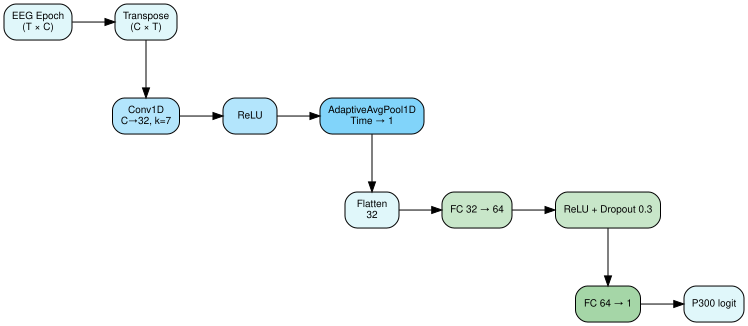

In [ ]:
from graphviz import Digraph

dot = Digraph(format='pdf')
dot.attr(rankdir='TB', fontsize='12', splines='ortho', nodesep='0.6', ranksep='0.8')

# --- Estilo base de nodos ---
node_style = {
    'shape': 'box',
    'style': 'filled,rounded',
    'fontname': 'Helvetica',
    'fontsize': '10',
    'fillcolor': '#e0f7fa'  # color base
}

# --- Nodos ---
dot.node("X", "EEG Epoch\n(T × C)", **node_style)
dot.node("T", "Transpose\n(C × T)", **node_style)

dot.node("C1", "Conv1D\nC→32, k=7", **{**node_style, 'fillcolor':'#b3e5fc'})
dot.node("R1", "ReLU", **{**node_style, 'fillcolor':'#b3e5fc'})
dot.node("P", "AdaptiveAvgPool1D\nTime → 1", **{**node_style, 'fillcolor':'#81d4fa'})

dot.node("F", "Flatten\n32", **node_style)
dot.node("FC1", "FC 32 → 64", **{**node_style, 'fillcolor':'#c8e6c9'})
dot.node("R2", "ReLU + Dropout 0.3", **{**node_style, 'fillcolor':'#c8e6c9'})

dot.node("FC2", "FC 64 → 1", **{**node_style, 'fillcolor':'#a5d6a7'})
dot.node("Y", "P300 logit", **node_style)

# --- Niveles (filas) ---
with dot.subgraph() as s:
    s.attr(rank='same')
    s.node("X")
    s.node("T")

with dot.subgraph() as s:
    s.attr(rank='same')
    s.node("C1")
    s.node("R1")
    s.node("P")

with dot.subgraph() as s:
    s.attr(rank='same')
    s.node("F")
    s.node("FC1")
    s.node("R2")

with dot.subgraph() as s:
    s.attr(rank='same')
    s.node("FC2")
    s.node("Y")

# --- Conexiones ---
dot.edge("X","T")
dot.edge("T","C1")
dot.edge("C1","R1")
dot.edge("R1","P")
dot.edge("P","F")
dot.edge("F","FC1")
dot.edge("FC1","R2")
dot.edge("R2","FC2")
dot.edge("FC2","Y")

dot


# Features

## Modelos clásicos

In [ ]:
X_epochs, y, subjects = [], [], []

for _, row in df_epochs.iterrows():
    chans = [np.asarray(ch, np.float32) for ch in row["data"]]
    min_len = min(len(ch) for ch in chans)
    chans = [ch[:min_len] for ch in chans]
    epoch = np.stack(chans, axis=0).T  # (T, C)
    X_epochs.append(epoch)
    y.append(row["label"])
    subjects.append(row["subject"])

X = np.stack(X_epochs)        # (n_epochs, T, C)
y = np.array(y)
subjects = np.array(subjects)
print("X shape:", X.shape)

for s in np.unique(subjects):
    idx = subjects == s
    mu = X[idx].mean(axis=(0,1), keepdims=True)
    sd = X[idx].std(axis=(0,1), keepdims=True)
    X[idx] = (X[idx] - mu) / (sd + 1e-6)

X shape: (28189, 206, 16)


In [ ]:
feature_sets = {
'Temporal': df_temp.drop(columns=['label','subject']).values,
'Espacial': df_spat.drop(columns=['label','subject']).values,
'Frecuencia': df_freq.drop(columns=['label','subject']).values
}

Sin SMOTE


=== Entrenando modelos con features Temporal ===

===== Fold 1/5 =====
LogReg     | ACC=0.766 | AUC=0.559 | F1=0.190
LDA_shrink | ACC=0.736 | AUC=0.557 | F1=0.186
LinearSVM  | ACC=0.757 | AUC=0.559 | F1=0.187


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:35:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.881 | AUC=0.531 | F1=0.070
[LightGBM] [Info] Number of positive: 2356, number of negative: 20256
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059533 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 59528
[LightGBM] [Info] Number of data points in the train set: 22612, number of used features: 238
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.881 | AUC=0.548 | F1=0.062

===== Fold 2/5 =====
LogReg     | ACC=0.663 | AUC=0.579 | F1=0.208
LDA_shrink | ACC=0.653 | AUC=0.580 | F1=0.204
LinearSVM  | ACC=0.656 | AUC=0.579 | F1=0.207


...

LightGBM   | ACC=0.858 | AUC=0.555 | F1=0.110

===== Fold 5/5 =====
LogReg     | ACC=0.716 | AUC=0.562 | F1=0.184
LDA_shrink | ACC=0.674 | AUC=0.575 | F1=0.209
LinearSVM  | ACC=0.719 | AUC=0.558 | F1=0.177


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:38:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.871 | AUC=0.543 | F1=0.068
[LightGBM] [Info] Number of positive: 2317, number of negative: 20154
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.061787 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 59528
[LightGBM] [Info] Number of data points in the train set: 22471, number of used features: 238
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.873 | AUC=0.515 | F1=0.092


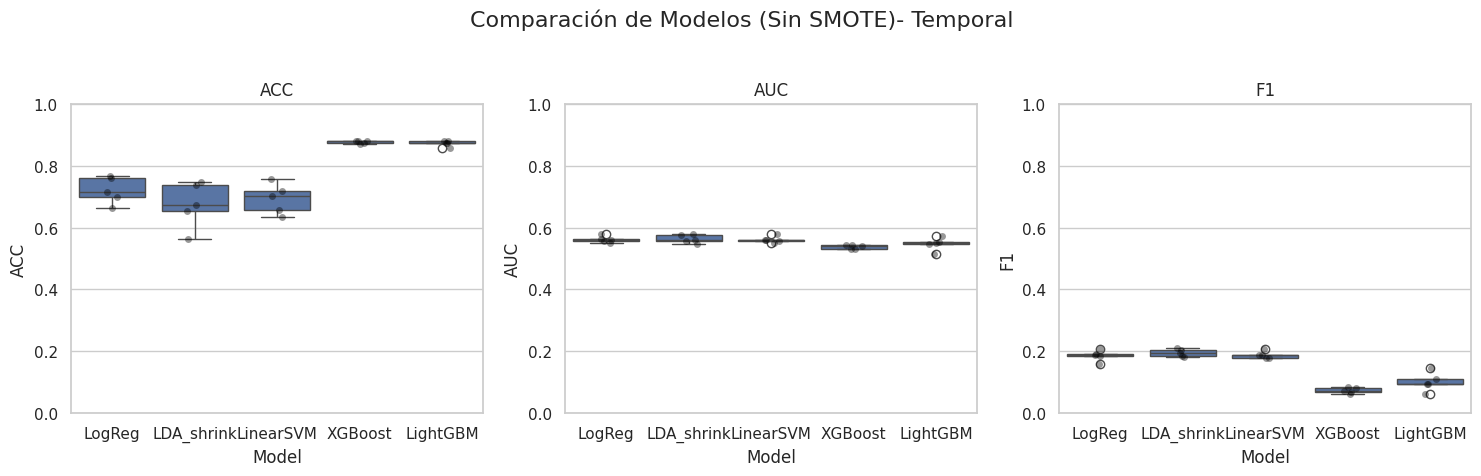


=== Entrenando modelos con features Espacial ===

===== Fold 1/5 =====
LogReg     | ACC=0.485 | AUC=0.519 | F1=0.169
LDA_shrink | ACC=0.483 | AUC=0.516 | F1=0.168
LinearSVM  | ACC=0.578 | AUC=0.521 | F1=0.164


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:38:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.866 | AUC=0.539 | F1=0.074
[LightGBM] [Info] Number of positive: 2356, number of negative: 20256
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011305 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12240
[LightGBM] [Info] Number of data points in the train set: 22612, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.864 | AUC=0.513 | F1=0.080

===== Fold 2/5 =====
LogReg     | ACC=0.400 | AUC=0.547 | F1=0.194
LDA_shrink | ACC=0.345 | AUC=0.547 | F1=0.192
LinearSVM  | ACC=0.394 | AUC=0.547 | F1=0.194


...

LightGBM   | ACC=0.849 | AUC=0.508 | F1=0.092

===== Fold 5/5 =====
LogReg     | ACC=0.415 | AUC=0.560 | F1=0.198
LDA_shrink | ACC=0.347 | AUC=0.560 | F1=0.198
LinearSVM  | ACC=0.364 | AUC=0.561 | F1=0.196


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.852 | AUC=0.529 | F1=0.089
[LightGBM] [Info] Number of positive: 2317, number of negative: 20154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12240
[LightGBM] [Info] Number of data points in the train set: 22471, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.854 | AUC=0.530 | F1=0.103


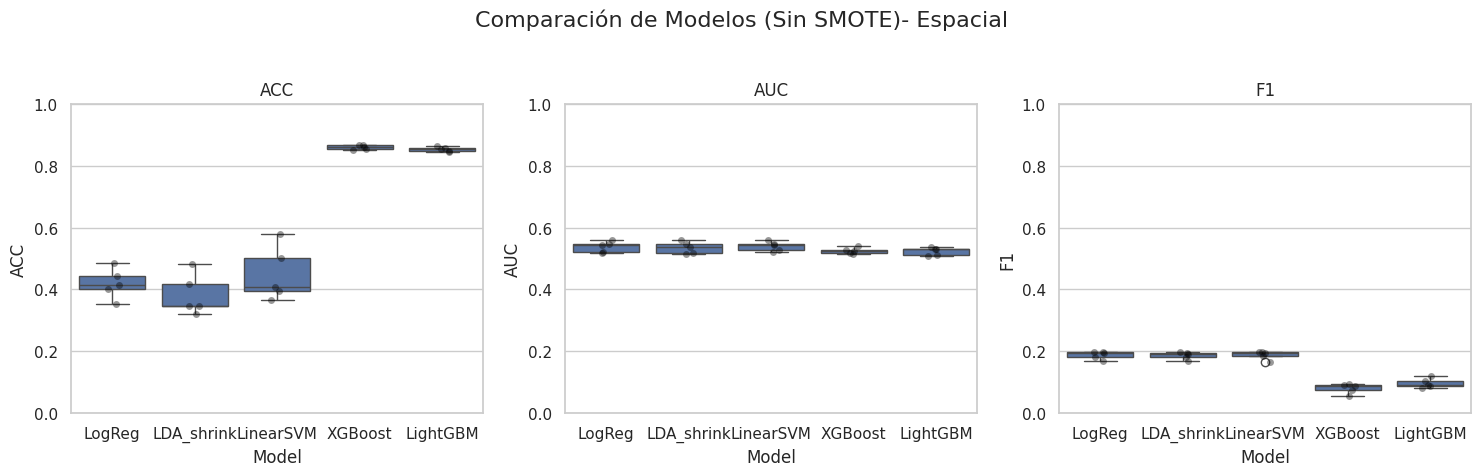


=== Entrenando modelos con features Frecuencia ===

===== Fold 1/5 =====
LogReg     | ACC=0.436 | AUC=0.553 | F1=0.183
LDA_shrink | ACC=0.443 | AUC=0.553 | F1=0.182
LinearSVM  | ACC=0.436 | AUC=0.553 | F1=0.182


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.860 | AUC=0.509 | F1=0.067
[LightGBM] [Info] Number of positive: 2356, number of negative: 20256
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 22612, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.849 | AUC=0.517 | F1=0.104

===== Fold 2/5 =====
LogReg     | ACC=0.477 | AUC=0.534 | F1=0.191
LDA_shrink | ACC=0.449 | AUC=0.536 | F1=0.188
LinearSVM  | ACC=0.476 | AUC=0.534 | F1=0.190


...

LightGBM   | ACC=0.836 | AUC=0.531 | F1=0.098

===== Fold 5/5 =====
LogReg     | ACC=0.588 | AUC=0.527 | F1=0.167
LDA_shrink | ACC=0.598 | AUC=0.528 | F1=0.168
LinearSVM  | ACC=0.586 | AUC=0.528 | F1=0.168


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.851 | AUC=0.524 | F1=0.086
[LightGBM] [Info] Number of positive: 2317, number of negative: 20154
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002588 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 22471, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.843 | AUC=0.522 | F1=0.100


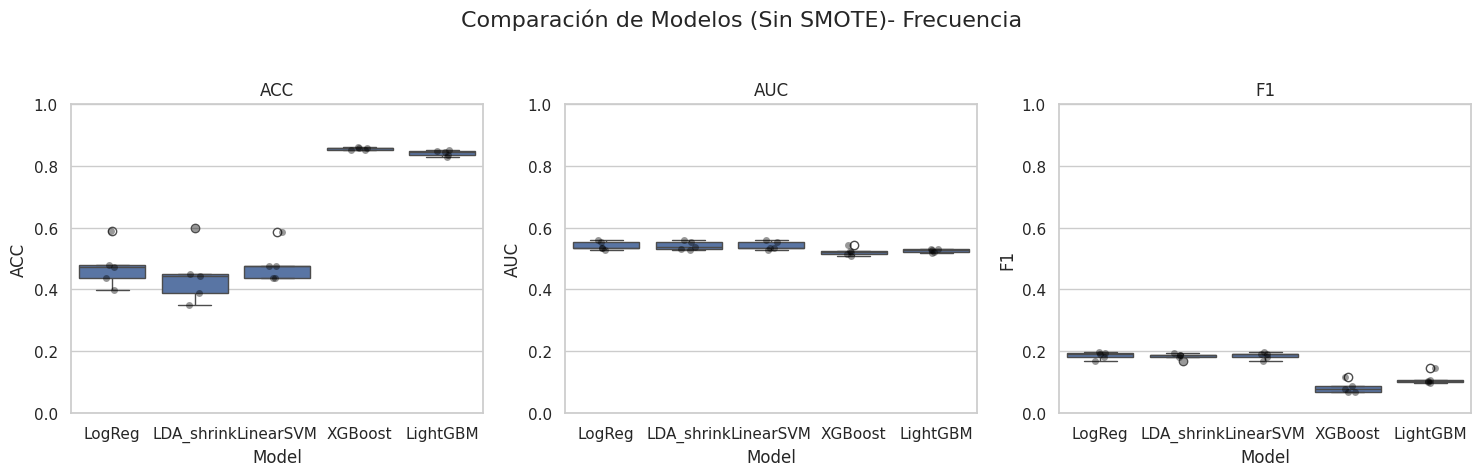

In [ ]:
results_nosmote = []
preds_nosmote = []

for feat_name, X_feat in feature_sets.items():
    print(f"\n=== Entrenando modelos con features {feat_name} ===")

    results_df, preds_df = train_classic(
        X_feat, y, subjects, models,
        n_splits=5,
        n_xdawn=4,
        use_smote=False,
        verbose=True,
        feature_type=feat_name
    )

    plot_metrics(results_df, title=f"Comparación de Modelos (Sin SMOTE)- {feat_name}")

    results_df["feature_type"] = feat_name
    results_nosmote.append(results_df)
    preds_nosmote.append(preds_df)

results_nosmote_df = pd.concat(results_nosmote, ignore_index=True)
preds_nosmote_df = pd.concat(preds_nosmote, ignore_index=True)

Con SMOTE


=== Entrenando modelos con features Temporal ===

===== Fold 1/5 =====
LogReg     | ACC=0.728 | AUC=0.549 | F1=0.166
LDA_shrink | ACC=0.708 | AUC=0.549 | F1=0.172
LinearSVM  | ACC=0.739 | AUC=0.549 | F1=0.161


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:40:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.859 | AUC=0.519 | F1=0.079
[LightGBM] [Info] Number of positive: 20256, number of negative: 20256
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.114929 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 60690
[LightGBM] [Info] Number of data points in the train set: 40512, number of used features: 238
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.807 | AUC=0.525 | F1=0.111

===== Fold 2/5 =====
LogReg     | ACC=0.650 | AUC=0.552 | F1=0.195
LDA_shrink | ACC=0.647 | AUC=0.552 | F1=0.191
LinearSVM  | ACC=0.635 | AUC=0.551 | F1=0.196


...

LightGBM   | ACC=0.755 | AUC=0.509 | F1=0.123

===== Fold 5/5 =====
LogReg     | ACC=0.627 | AUC=0.537 | F1=0.178
LDA_shrink | ACC=0.674 | AUC=0.530 | F1=0.166
LinearSVM  | ACC=0.635 | AUC=0.533 | F1=0.171


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:47:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.857 | AUC=0.504 | F1=0.101
[LightGBM] [Info] Number of positive: 20154, number of negative: 20154
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.118501 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 60690
[LightGBM] [Info] Number of data points in the train set: 40308, number of used features: 238
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.797 | AUC=0.517 | F1=0.112


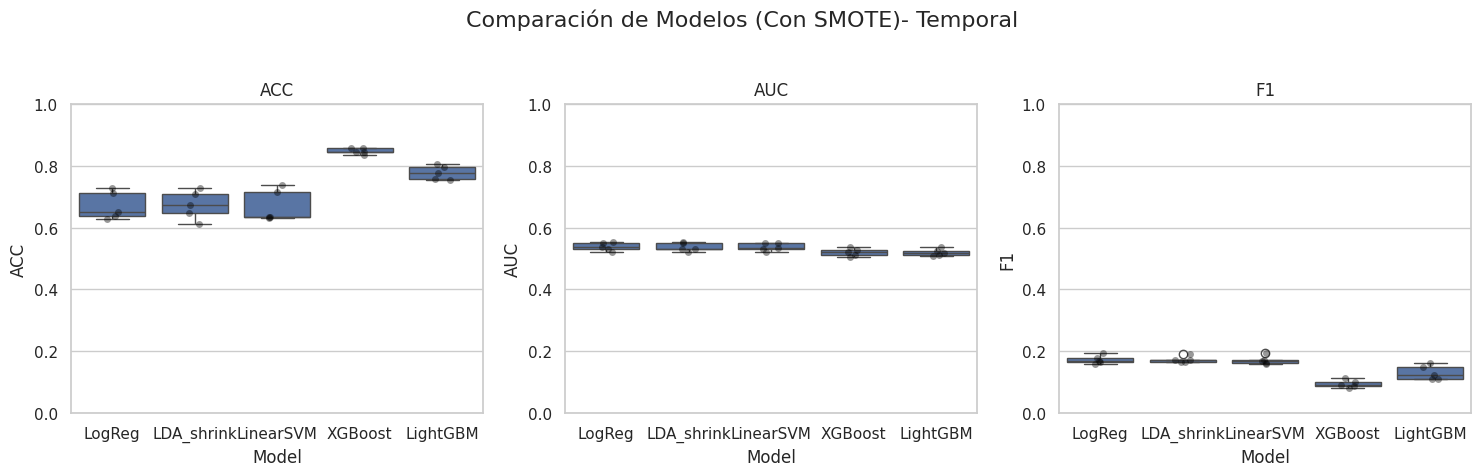


=== Entrenando modelos con features Espacial ===

===== Fold 1/5 =====
LogReg     | ACC=0.579 | AUC=0.521 | F1=0.173
LDA_shrink | ACC=0.496 | AUC=0.522 | F1=0.173
LinearSVM  | ACC=0.532 | AUC=0.522 | F1=0.172


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:47:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.857 | AUC=0.516 | F1=0.089
[LightGBM] [Info] Number of positive: 20256, number of negative: 20256
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12240
[LightGBM] [Info] Number of data points in the train set: 40512, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.814 | AUC=0.506 | F1=0.107

===== Fold 2/5 =====
LogReg     | ACC=0.409 | AUC=0.548 | F1=0.191
LDA_shrink | ACC=0.336 | AUC=0.546 | F1=0.193
LinearSVM  | ACC=0.387 | AUC=0.550 | F1=0.195


...

LightGBM   | ACC=0.763 | AUC=0.533 | F1=0.143

===== Fold 5/5 =====
LogReg     | ACC=0.302 | AUC=0.554 | F1=0.193
LDA_shrink | ACC=0.369 | AUC=0.554 | F1=0.195
LinearSVM  | ACC=0.341 | AUC=0.554 | F1=0.192


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:48:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.843 | AUC=0.522 | F1=0.102
[LightGBM] [Info] Number of positive: 20154, number of negative: 20154
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018940 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12240
[LightGBM] [Info] Number of data points in the train set: 40308, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.822 | AUC=0.524 | F1=0.116


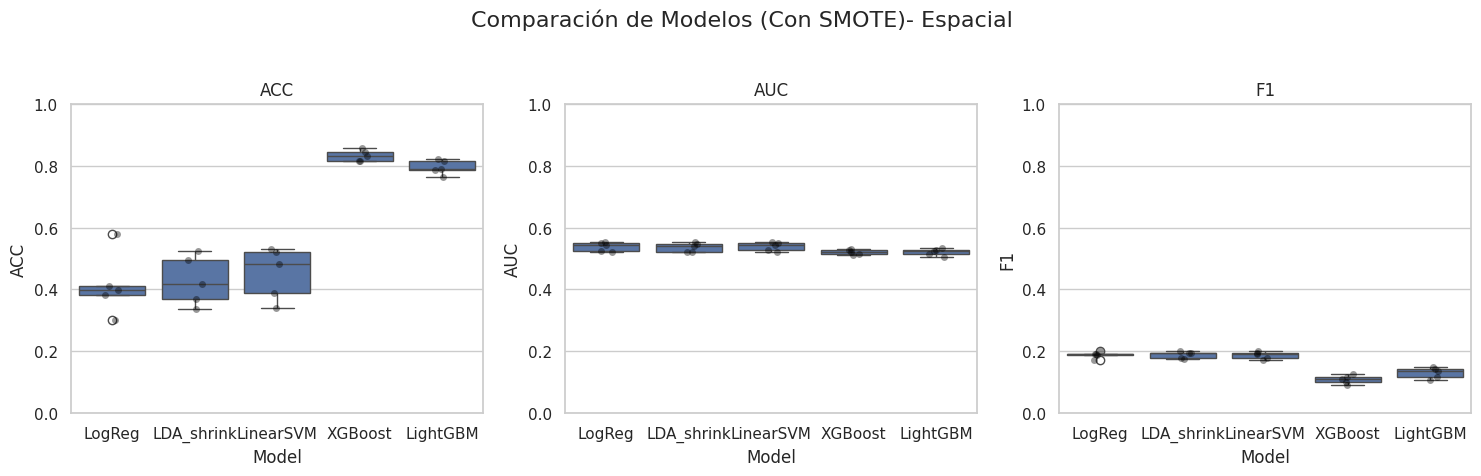


=== Entrenando modelos con features Frecuencia ===

===== Fold 1/5 =====
LogReg     | ACC=0.617 | AUC=0.551 | F1=0.179
LDA_shrink | ACC=0.616 | AUC=0.551 | F1=0.179
LinearSVM  | ACC=0.616 | AUC=0.551 | F1=0.179


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:48:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.854 | AUC=0.500 | F1=0.113
[LightGBM] [Info] Number of positive: 20256, number of negative: 20256
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004726 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 40512, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.735 | AUC=0.503 | F1=0.137

===== Fold 2/5 =====
LogReg     | ACC=0.410 | AUC=0.533 | F1=0.190
LDA_shrink | ACC=0.422 | AUC=0.533 | F1=0.190
LinearSVM  | ACC=0.422 | AUC=0.533 | F1=0.190


...

LightGBM   | ACC=0.720 | AUC=0.503 | F1=0.143

===== Fold 5/5 =====
LogReg     | ACC=0.562 | AUC=0.527 | F1=0.166
LDA_shrink | ACC=0.565 | AUC=0.527 | F1=0.166
LinearSVM  | ACC=0.563 | AUC=0.527 | F1=0.168


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:48:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost    | ACC=0.836 | AUC=0.518 | F1=0.105
[LightGBM] [Info] Number of positive: 20154, number of negative: 20154
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 40308, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM   | ACC=0.736 | AUC=0.519 | F1=0.159


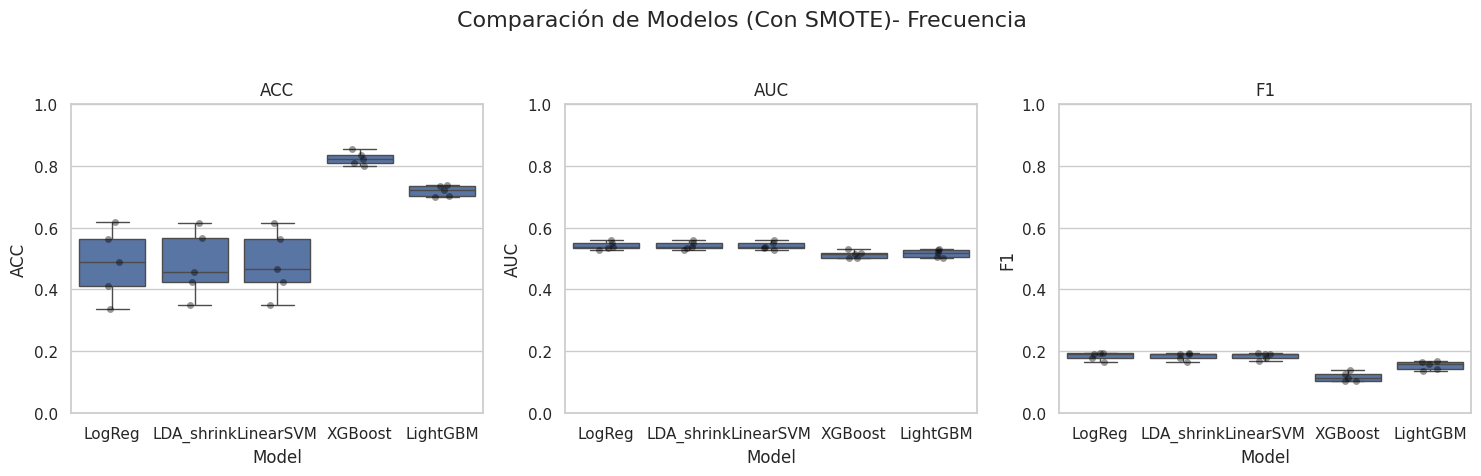

In [ ]:
results_smote = []
preds_smote = []

for feat_name, X_feat in feature_sets.items():
    print(f"\n=== Entrenando modelos con features {feat_name} ===")

    results_df, preds_df = train_classic(
        X_feat, y, subjects, models,
        n_splits=5,
        n_xdawn=4,
        use_smote=True,
        verbose=True,
        feature_type=feat_name
    )

    plot_metrics(results_df, title=f"Comparación de Modelos (Con SMOTE)- {feat_name}")

    results_df["feature_type"] = feat_name
    results_smote.append(results_df)
    preds_smote.append(preds_df)

results_smote_df = pd.concat(results_smote, ignore_index=True)
preds_smote_df = pd.concat(preds_smote, ignore_index=True)

In [ ]:
print("\nResultados por fold y tipo de feature:")
print(results_nosmote_df)


# Resumen promedio por modelo y tipo de feature
print("\nPromedio por modelo y tipo de feature:")
print(results_nosmote_df.groupby(['feature_type','model'])[['acc', 'auc', 'f1']].mean())


Resultados por fold y tipo de feature:
         model  fold       acc       auc        f1 feature_type
0       LogReg     0  0.765645  0.558591  0.189709     Temporal
1   LDA_shrink     0  0.736417  0.556724  0.186047     Temporal
2    LinearSVM     0  0.757038  0.558770  0.187163     Temporal
3      XGBoost     0  0.880940  0.530847  0.070028     Temporal
4     LightGBM     0  0.881119  0.547647  0.062235     Temporal
..         ...   ...       ...       ...       ...          ...
70      LogReg     4  0.587793  0.527449  0.167432   Frecuencia
71  LDA_shrink     4  0.597761  0.528007  0.168474   Frecuencia
72   LinearSVM     4  0.585869  0.527683  0.167955   Frecuencia
73     XGBoost     4  0.851172  0.523623  0.085929   Frecuencia
74    LightGBM     4  0.843127  0.521708  0.100301   Frecuencia

[75 rows x 6 columns]

Promedio por modelo y tipo de feature:
                              acc       auc        f1
feature_type model                                   
Espacial     LDA_shri

In [ ]:
print("\nResultados por fold y tipo de feature:")
print(results_smote_df)


# Resumen promedio por modelo y tipo de feature
print("\nPromedio por modelo y tipo de feature:")
print(results_smote_df.groupby(['feature_type','model'])[['acc', 'auc', 'f1']].mean())


Resultados por fold y tipo de feature:
         model  fold       acc       auc        f1 feature_type
0       LogReg     0  0.727990  0.549008  0.166025     Temporal
1   LDA_shrink     0  0.708087  0.548743  0.171923     Temporal
2    LinearSVM     0  0.738928  0.548854  0.161290     Temporal
3      XGBoost     0  0.858705  0.519343  0.079439     Temporal
4     LightGBM     0  0.806706  0.525144  0.110561     Temporal
..         ...   ...       ...       ...       ...          ...
70      LogReg     4  0.562085  0.526641  0.166445   Frecuencia
71  LDA_shrink     4  0.564533  0.526695  0.166109   Frecuencia
72   LinearSVM     4  0.562784  0.526682  0.167776   Frecuencia
73     XGBoost     4  0.835957  0.518335  0.104962   Frecuencia
74    LightGBM     4  0.736446  0.519178  0.158571   Frecuencia

[75 rows x 6 columns]

Promedio por modelo y tipo de feature:
                              acc       auc        f1
feature_type model                                   
Espacial     LDA_shri

## Ensemble

Sin SMOTE

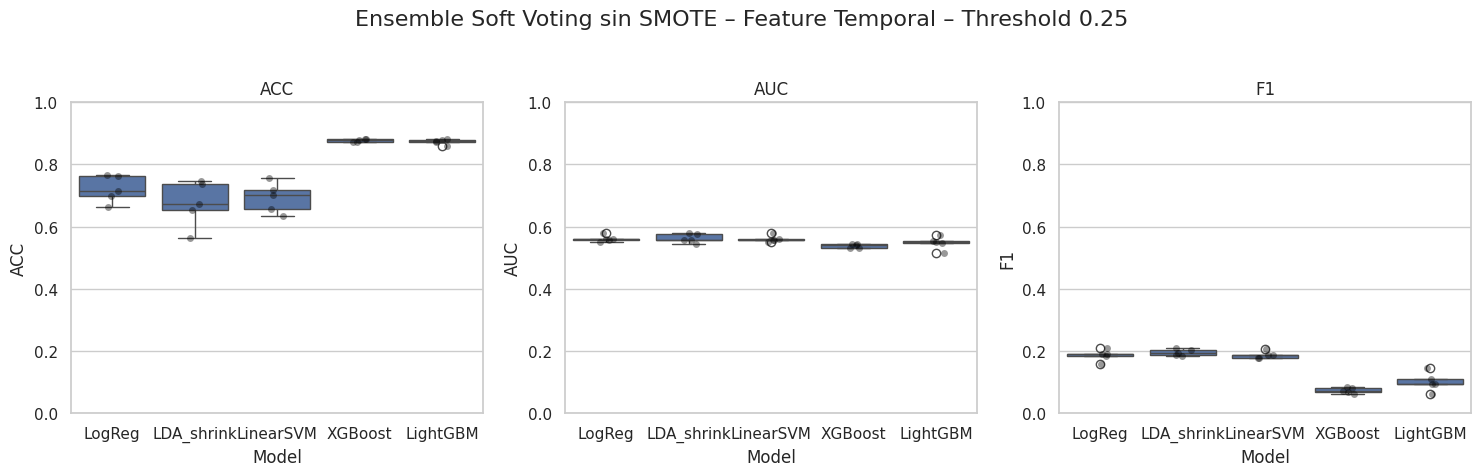

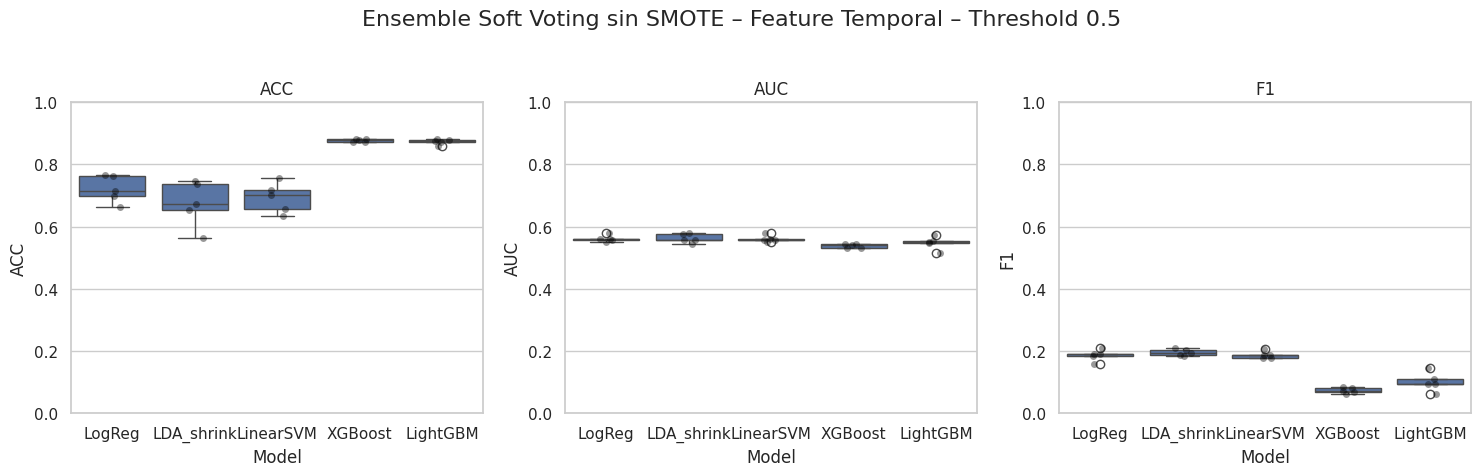

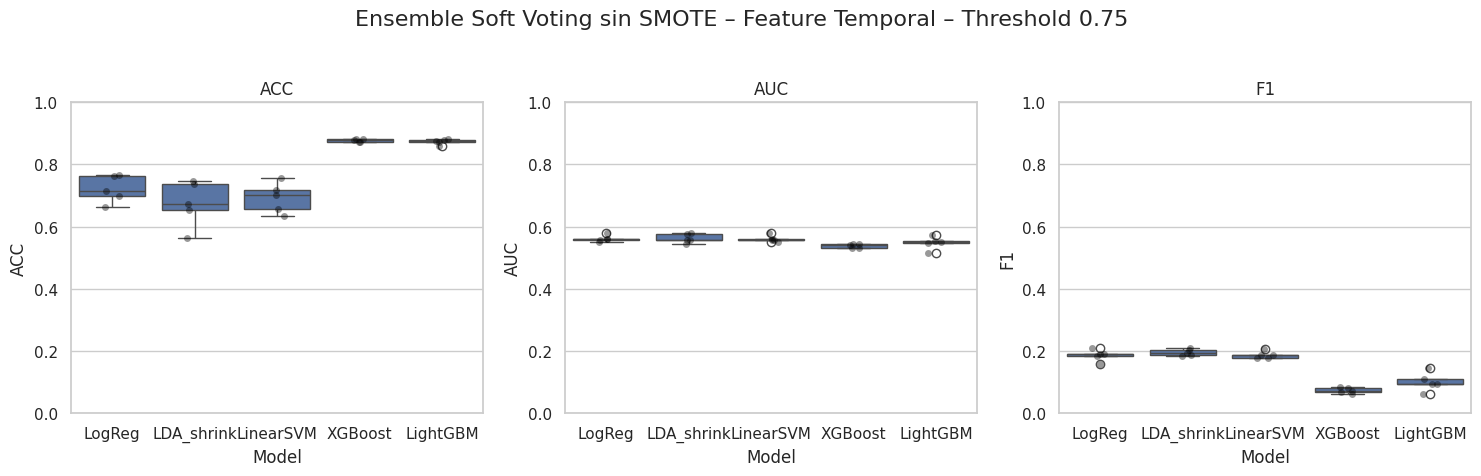

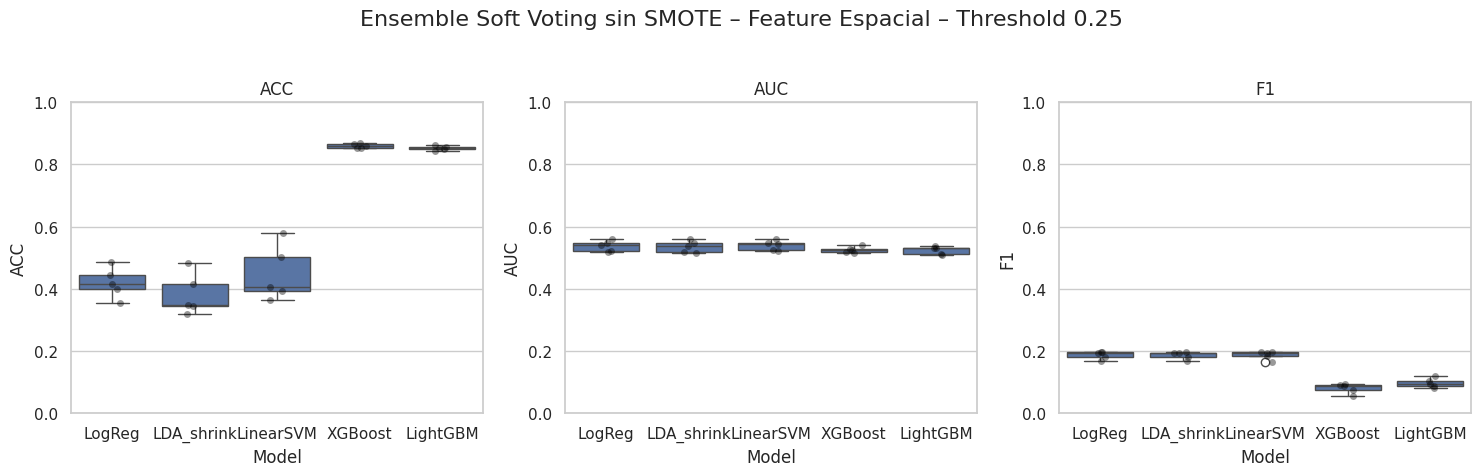

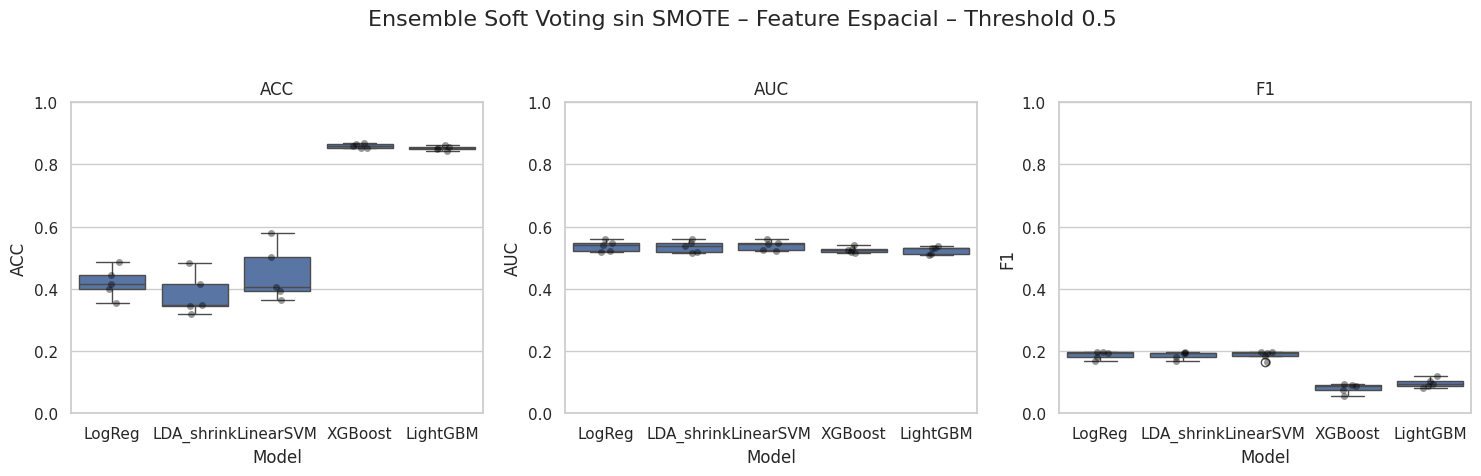

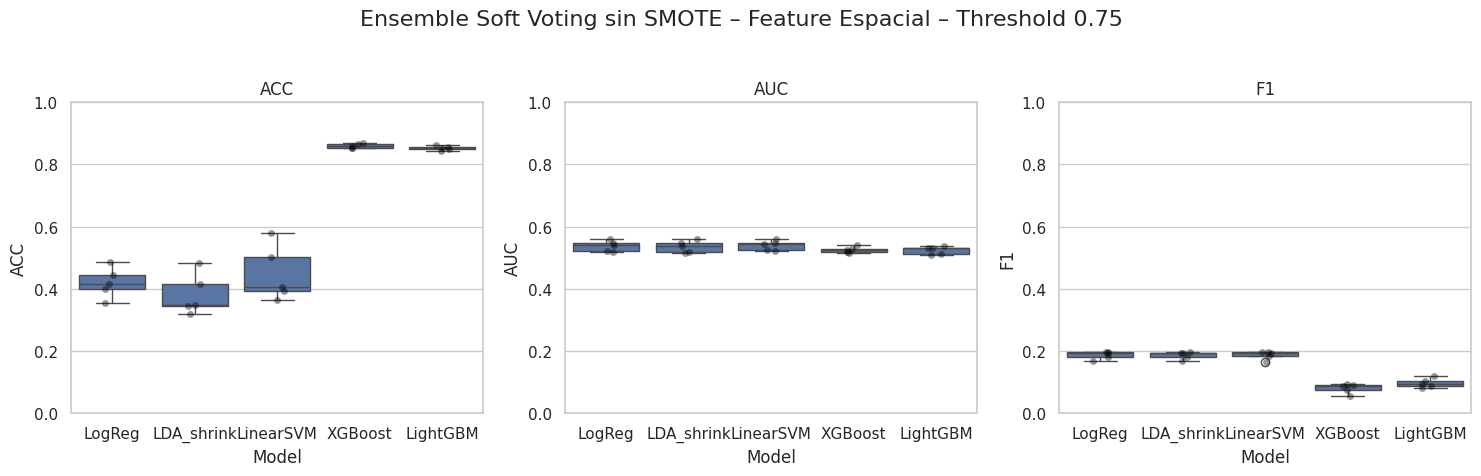

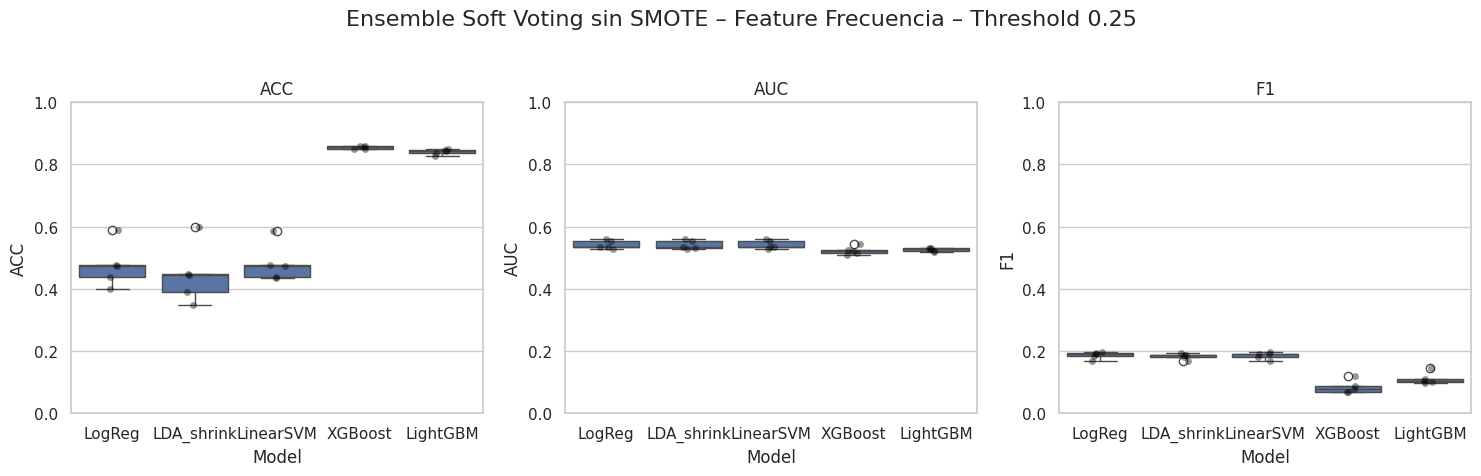

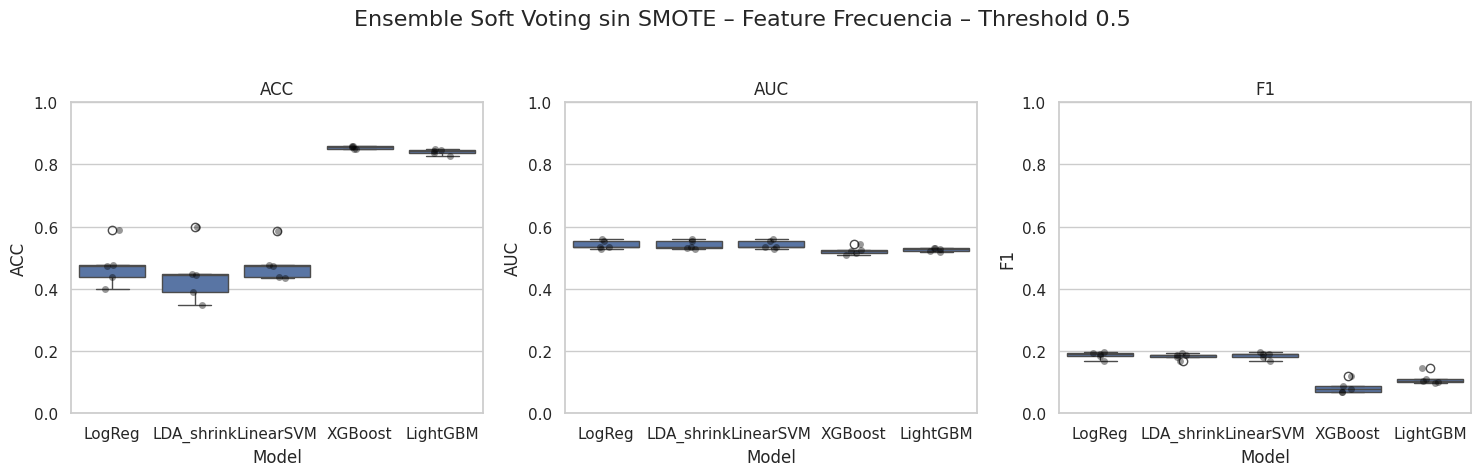

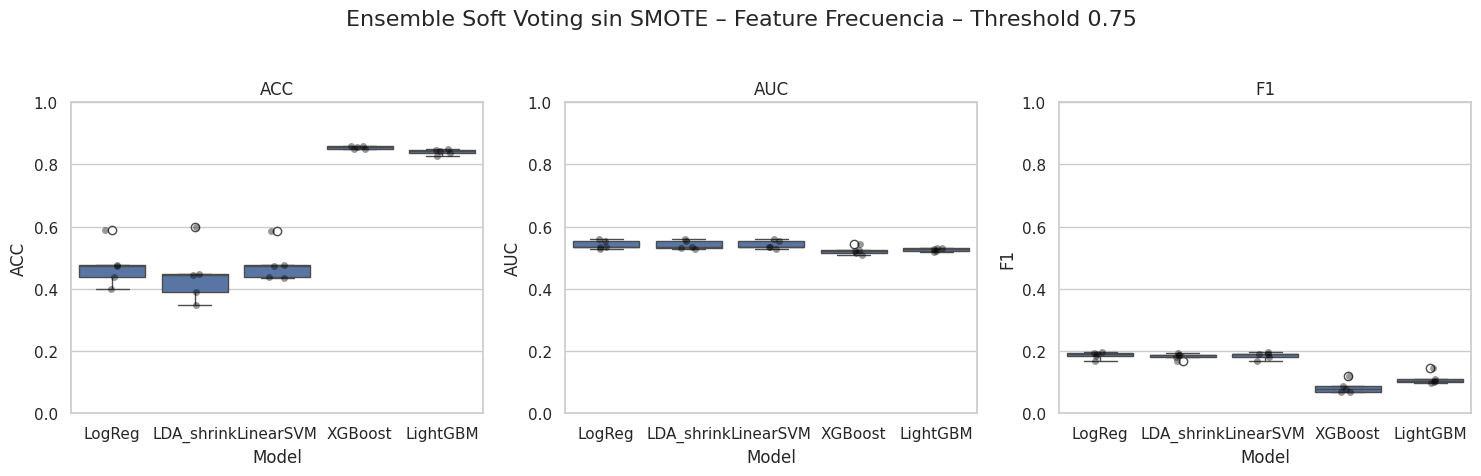

In [ ]:
thresholds = [0.25, 0.5, 0.75]
feature_types = ["Temporal", "Espacial", "Frecuencia"]

for feat in feature_types:
    for thr in thresholds:

        # ---- Ensemble para este umbral ----
        ens_results_df, _ = ensemble_soft_voting_from_preds(
            preds_nosmote_df,
            threshold=thr
        )

        # Filtrar SOLO este feature
        ens_results_df = ens_results_df[
            ens_results_df["feature_type"] == feat
        ]

        # Etiqueta clara del ensemble
        ens_results_df["model"] = (
            ens_results_df["model"] + f" | Ensemble thr={thr}"
        )

        # ---- Resultados base SOLO de este feature ----
        base_results_df = results_nosmote_df[
            results_nosmote_df["feature_type"] == feat
        ]

        # ---- Combinar base + ensemble ----
        nosmote_results_feat_thr_df = pd.concat(
            [base_results_df, ens_results_df],
            ignore_index=True
        )

        # ---- Plot (UNA figura) ----
        plot_metrics(
            nosmote_results_feat_thr_df,
            title=(
                f"Ensemble Soft Voting sin SMOTE – "
                f"Feature {feat} – Threshold {thr}"
            )
        )


Con SMOTE

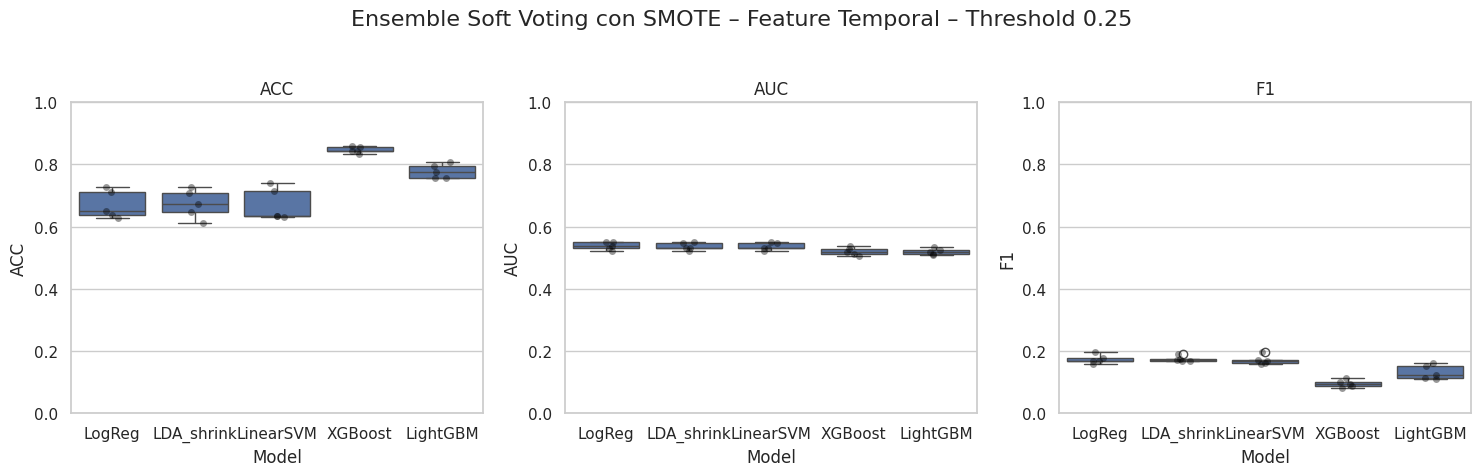

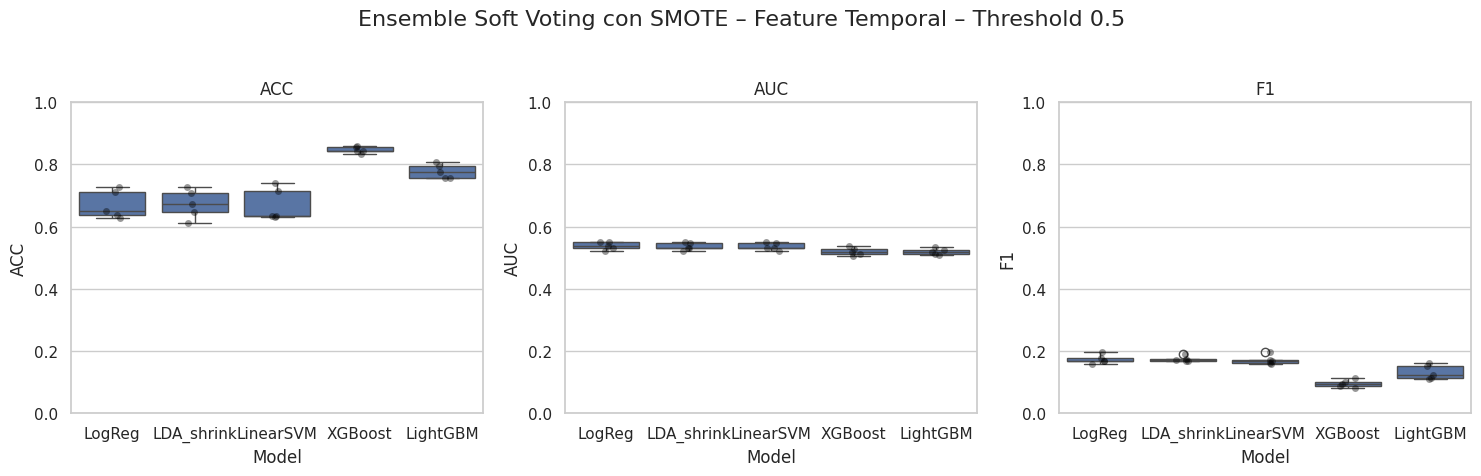

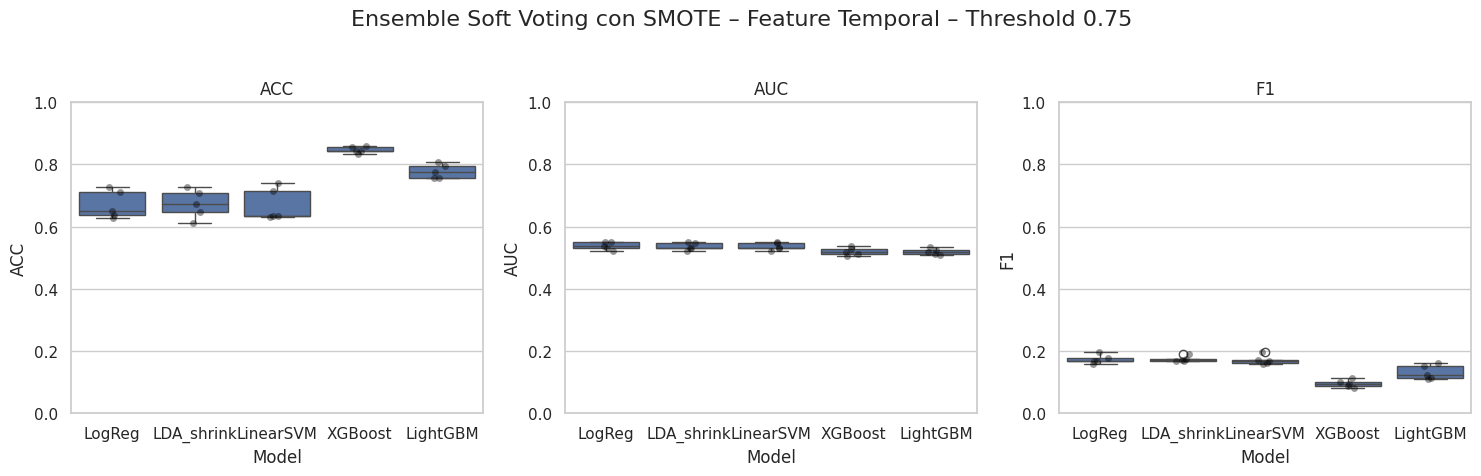

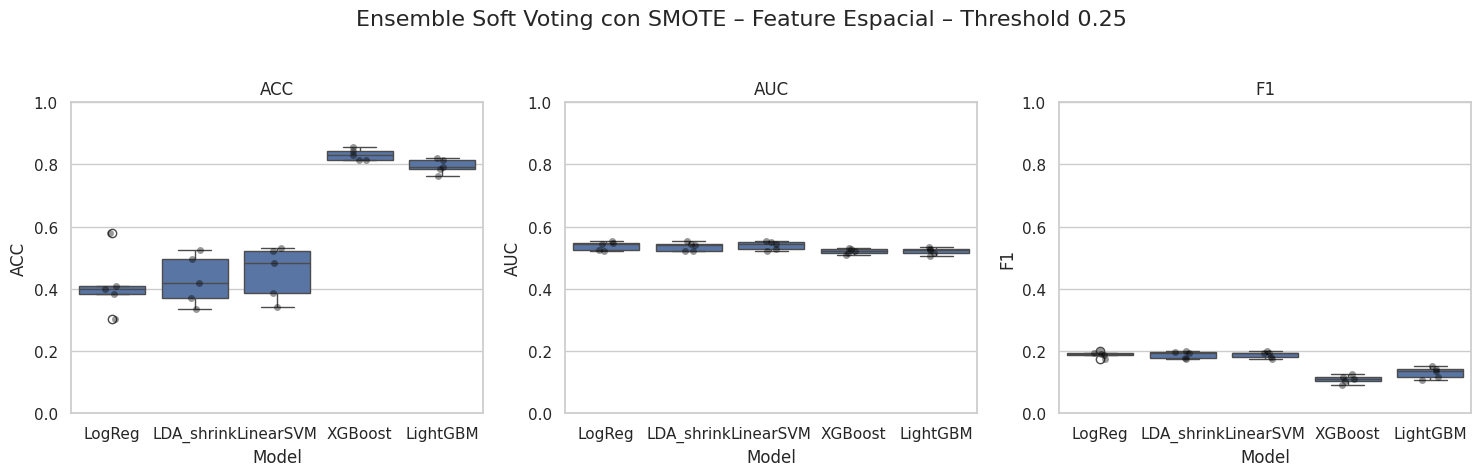

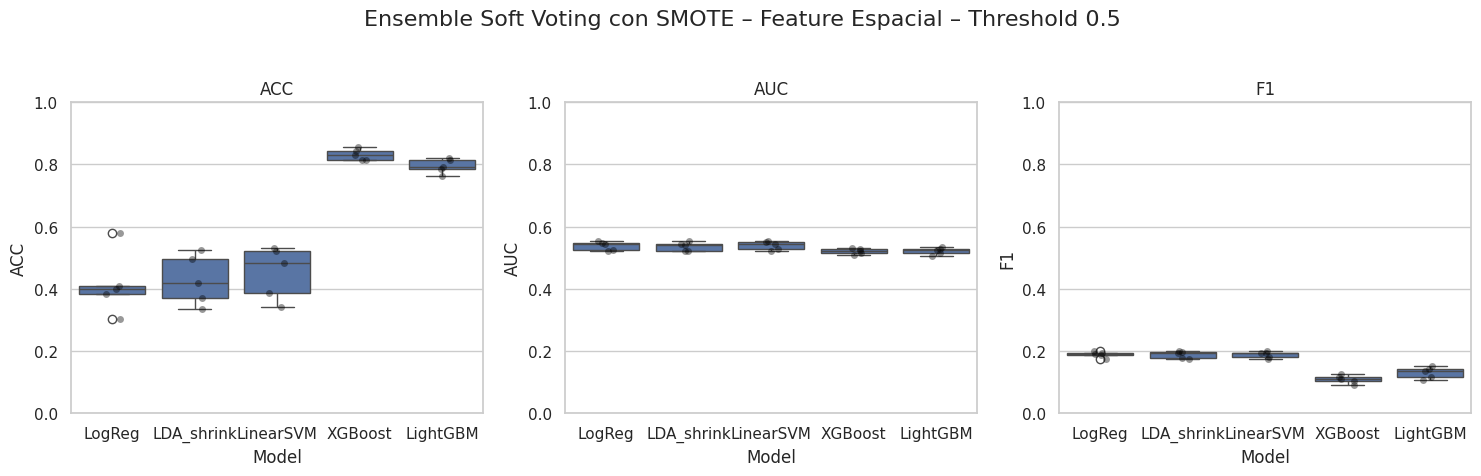

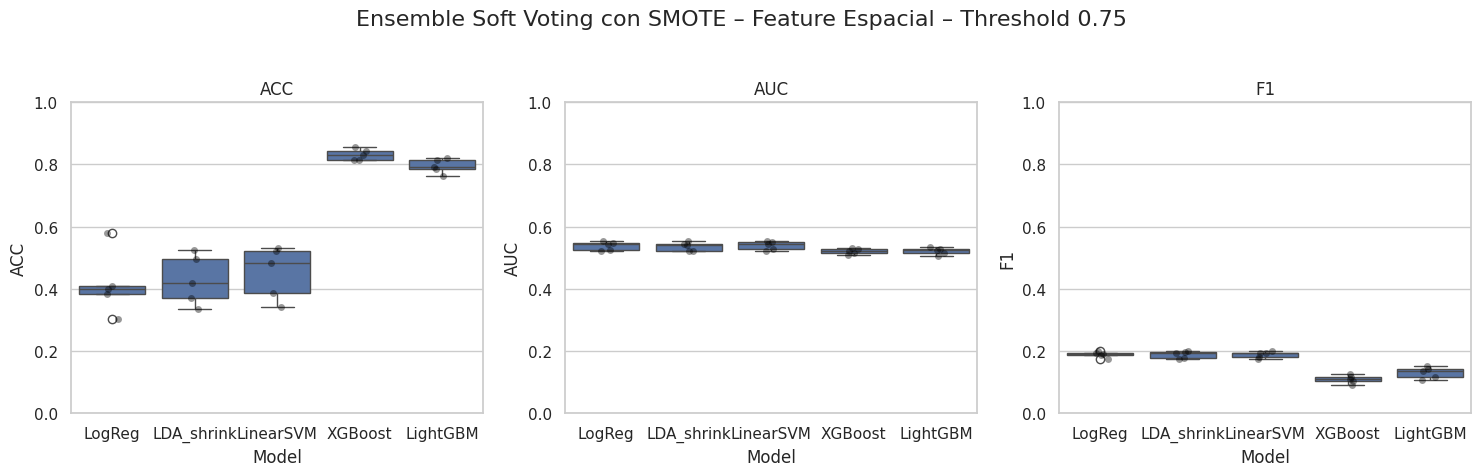

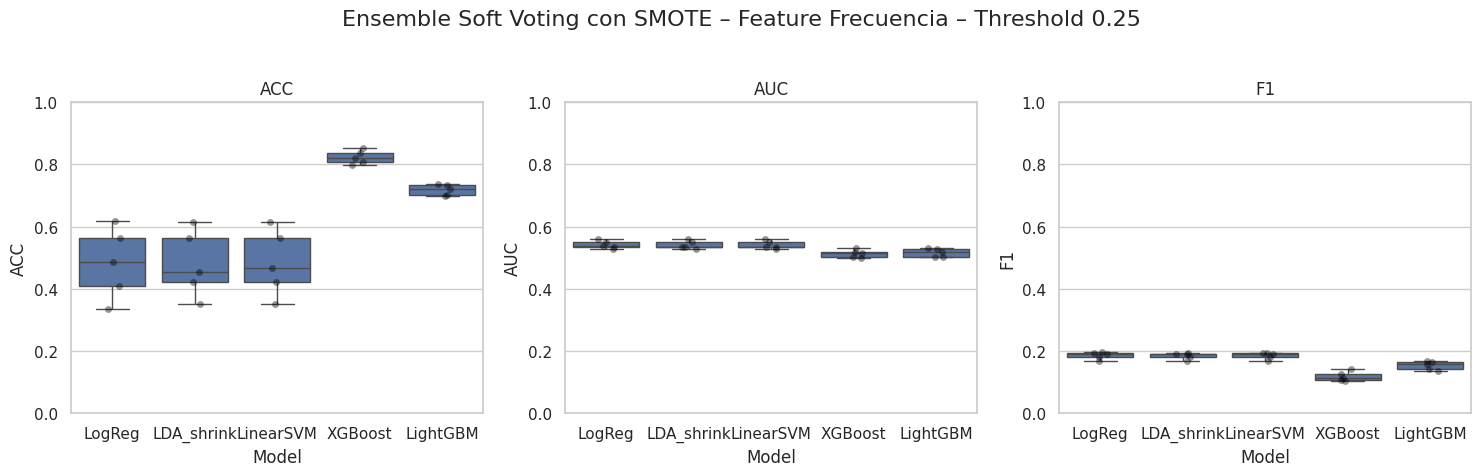

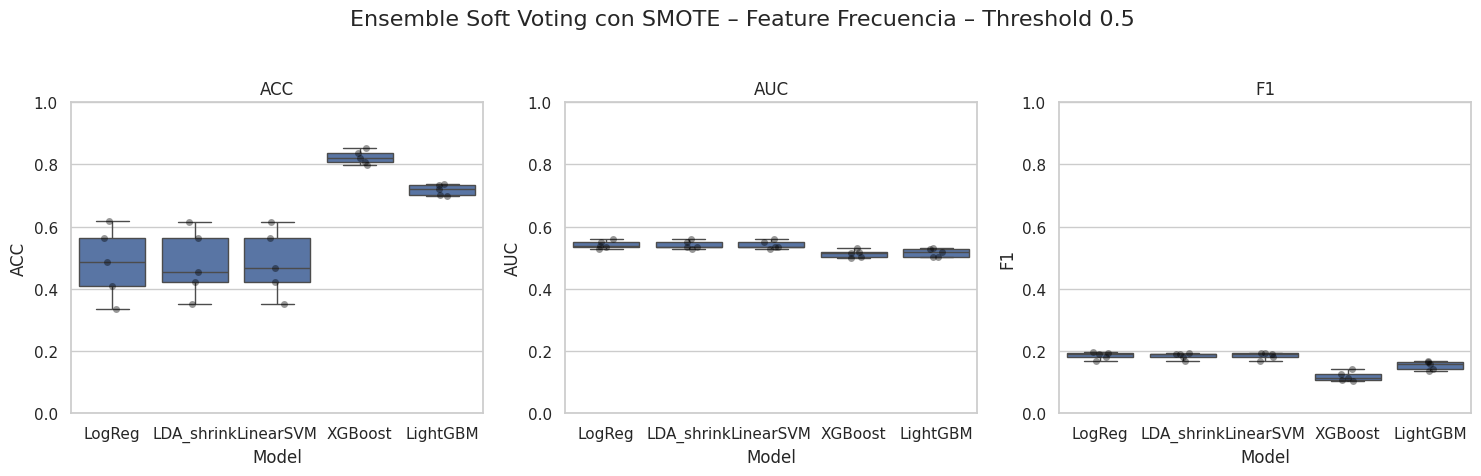

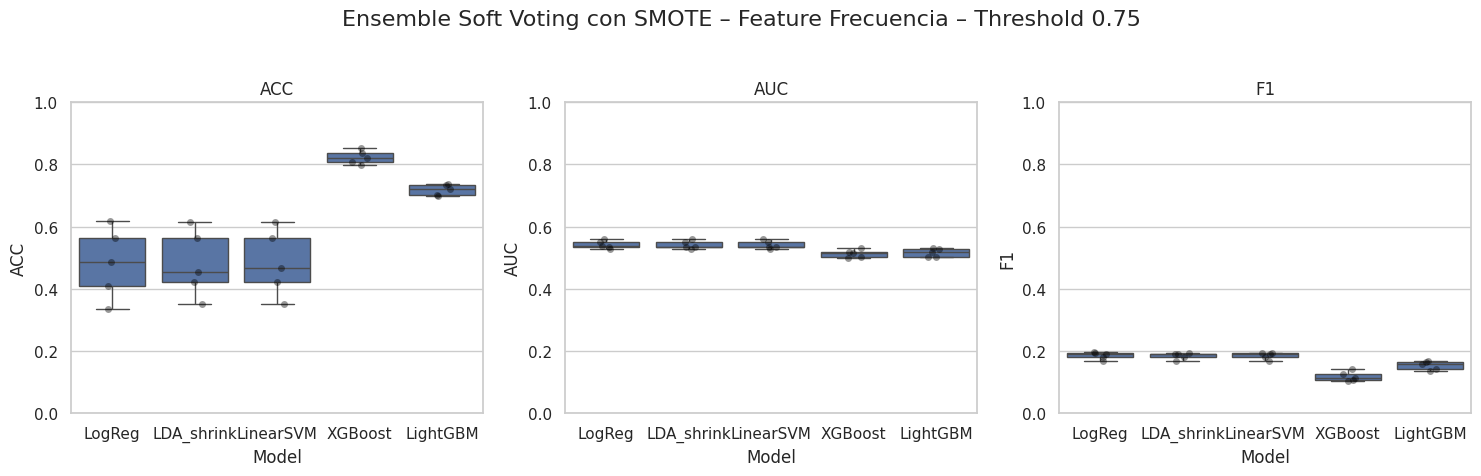

In [ ]:
thresholds = [0.25, 0.5, 0.75]
feature_types = ["Temporal", "Espacial", "Frecuencia"]

for feat in feature_types:
    for thr in thresholds:

        # ---- Ensemble para este umbral ----
        ens_results_df, _ = ensemble_soft_voting_from_preds(
            preds_smote_df,
            threshold=thr
        )

        # Filtrar SOLO este feature
        ens_results_df = ens_results_df[
            ens_results_df["feature_type"] == feat
        ]

        # Etiqueta clara del ensemble
        ens_results_df["model"] = (
            ens_results_df["model"] + f" | Ensemble thr={thr}"
        )

        # ---- Resultados base SOLO de este feature ----
        base_results_df = results_smote_df[
            results_smote_df["feature_type"] == feat
        ]

        # ---- Combinar base + ensemble ----
        smote_results_feat_thr_df = pd.concat(
            [base_results_df, ens_results_df],
            ignore_index=True
        )

        # ---- Plot (UNA figura) ----
        plot_metrics(
            smote_results_feat_thr_df,
            title=(
                f"Ensemble Soft Voting con SMOTE – "
                f"Feature {feat} – Threshold {thr}"
            )
        )
